
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [293]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las columnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

![see](https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png?raw=true)

## Laboratorio 1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



# Solución laboratorio 1

## Pregunta 1

In [294]:
df["isla"]

0      Torgersen
1      Torgersen
2      Torgersen
3      Torgersen
4      Torgersen
         ...    
328       Biscoe
329       Biscoe
330       Biscoe
331       Biscoe
332       Biscoe
Name: isla, Length: 333, dtype: str

In [295]:
df_torgersen = df[df["isla"] == "Torgersen"] # Se escoge la columna


resultado_max = df_torgersen[df_torgersen["profundidad_pico (mm)"] == df_torgersen["profundidad_pico (mm)"].max()] # con la columna escogida se busca el máximo
resultado_max



,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
14,Adelie,Torgersen,46.0,21.5,194.0,4200.0,Male


In [296]:
# con .iloc pongo la fila
print("Profundidad máxima de los picos: ",df["profundidad_pico (mm)"].iloc[14])

Profundidad máxima de los picos:  21.5


In [297]:

df_torgersen = df[df["isla"] == "Torgersen"]


resultado_min = df_torgersen[df_torgersen["profundidad_pico (mm)"] == df_torgersen["profundidad_pico (mm)"].min()]
resultado_min

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
118,Adelie,Torgersen,35.2,15.9,186.0,3050.0,Female


In [298]:
print("Profundidad mínima de los picos: ",df["profundidad_pico (mm)"].iloc[118] )

Profundidad mínima de los picos:  15.9


## Pregunta 2

In [299]:
localizacion = df["masa_corporal (g)"].argmax()

df[["isla","especie","genero"]].iloc[localizacion]

isla       Biscoe
especie    Gentoo
genero       Male
Name: 231, dtype: str

De la isla Biscoe, de especie Gentoo y género masculino es el pingüino con la mayor masa corporal

## Pregunta 3

In [300]:
df_otrasIslas = df[df["especie"] != "Gentoo"]
masa_corporal_gentoo = df_otrasIslas[df_otrasIslas["genero"]== "Male"]

media_masa_corporal = masa_corporal_gentoo["masa_corporal (g)"].mean()
media_masa_corporal

np.float64(4010.2803738317757)

In [301]:
print("La media es d ela masa corporal de los pingüinos macho que no son de Getoo: ",media_masa_corporal )

La media es d ela masa corporal de los pingüinos macho que no son de Getoo:  4010.2803738317757


## Pregunta 4

<Axes: >

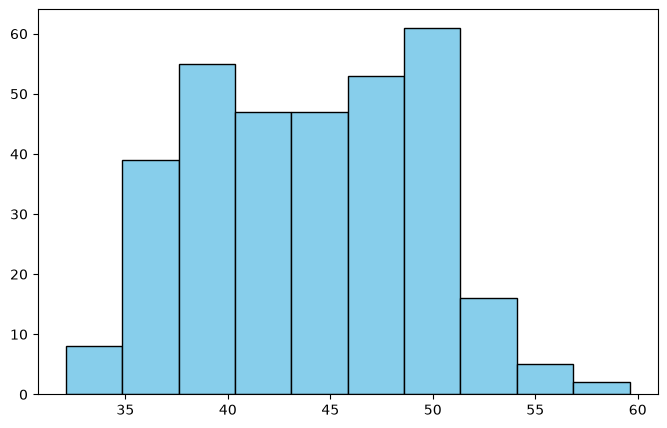

In [302]:
longitud_pico = df["longitud_pico (mm)"]

longitud_pico.hist(color='skyblue', edgecolor='black', grid=False, figsize=(8, 5))

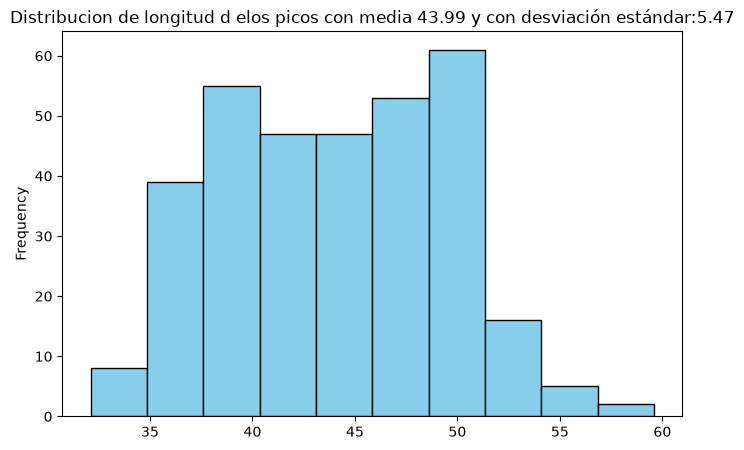

In [303]:
media = df["longitud_pico (mm)"].mean()
desviacion = df["longitud_pico (mm)"].std()


df["longitud_pico (mm)"].plot.hist(color='skyblue', edgecolor='black', grid=False, figsize=(8, 5))

plt.title(f"Distribucion de longitud d elos picos con media {media:.2f} y con desviación estándar:{desviacion:.2f}")

plt.show()

HACER TODO EN UN PLOT...? AÑADIR EL VALOR MEDIO EN EL HIST...

## Pregunta 5

### Islas y especies presentes en el conjunto de datos

In [304]:
lista_islas =df["isla"].values.tolist() # Pasar de dataframe a listas

set(lista_islas) # con el set() se utiliza para no repetir elementos


{'Biscoe', 'Dream', 'Torgersen'}

In [305]:
print("las islas son: ",set(lista_islas) )

las islas son:  {'Dream', 'Biscoe', 'Torgersen'}


In [306]:
lista_especies  = df["especie"].values.tolist()

set(lista_especies)

{'Adelie', 'Chinstrap', 'Gentoo'}

In [307]:
print("las especies son: ",set(lista_especies) )

las especies son:  {'Chinstrap', 'Gentoo', 'Adelie'}


### Frecuencia con la que se presenta las islas y especies presentes en el conjunto de datos

In [308]:
df[["especie","isla"]].value_counts()

especie    isla     
Gentoo     Biscoe       119
Chinstrap  Dream         68
Adelie     Dream         55
           Torgersen     47
           Biscoe        44
Name: count, dtype: int64

### Distribucion de la masa corporal de los pinüinos

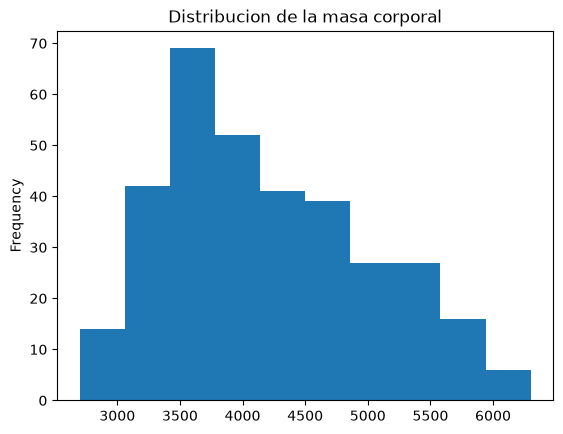

In [309]:
df["masa_corporal (g)"].plot.hist()
plt.title(f"Distribucion de la masa corporal")

plt.show()

MUY BIEN NOTA 4.0